# SARIMA Forecast

## 01 - Background

In this challenge, our goal is to apply the core concepts of time series analysis to univariate data (time-dependent sales).

We will follow these steps:
1. load and visualize the data;
2. train our models and make predictions;
3. use an econometric approach to model and forecast the series;
4. use Machine Learning to hack this model.

The dataset is provided by [Machine Learning Mastery](https://github.com/jbrownlee/). Run the line below to download it!

In [1]:
!curl https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly_champagne_sales.csv > data/monthly_champagne_sales.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1596  100  1596    0     0   4713      0 --:--:-- --:--:-- --:--:--  4721


## 02 - Data Loading
Let's start by loading the challenge's time series

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/monthly_champagne_sales.csv")
df.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


👉 Convert the "Month" column of the DataFrame to `Datetime` objects and set it as the index so it looks like this:
<br>

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/monthly_champagne_sales_objective.png" width=180>

In [3]:
df

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946
...,...,...
100,1972-05,4618
101,1972-06,5312
102,1972-07,4298
103,1972-08,1413


### Alternative - Let Pandas Do the Work

In [4]:
# We can also use pandas magic to handle the conversions from the start
df = pd.read_csv("data/monthly_champagne_sales.csv", parse_dates=['Month'], index_col='Month')
df.head()

,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


## 04 - Visualize and Interpret the Data

Great, thanks to this re-indexing you should now be able to easily plot the "Sales" (y-axis) values as a function of time (x-axis)

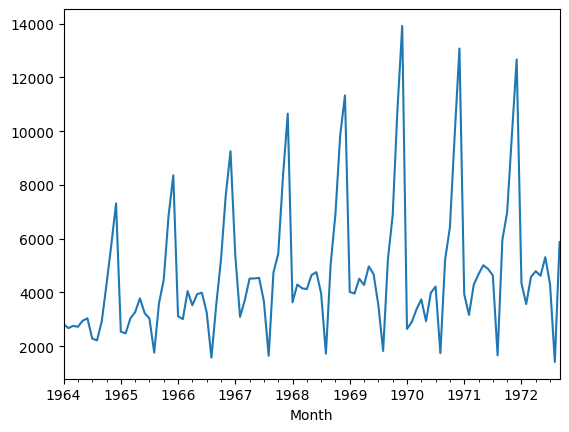

In [5]:
df["Sales"].plot();

If your code is correct, you should be able to see that this time series (TS) has the following properties:
- Not stationary (mean and variance are not constant).
- Exhibits strong seasonality.
- Appears to have a trend.

Let's look at the decomposition of the data into **trend**, **seasonality**, and **noise**. You should use statsmodels' [`seasonal_decompose`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) function. Read the docs and make sure you understand what this function does and how to use it, then:
1. Plot "Sales" with the "additive" model
2. Plot "Sales" with the "multiplicative" model

Pro tip: end your statsmodels plot method calls with a semicolon (`;`) to prevent double-plotting issues!

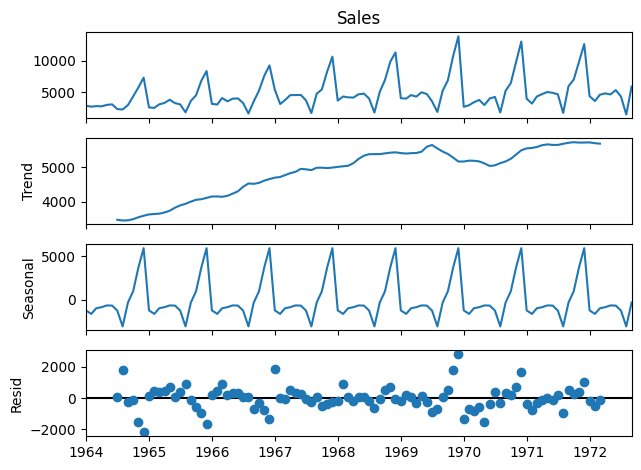

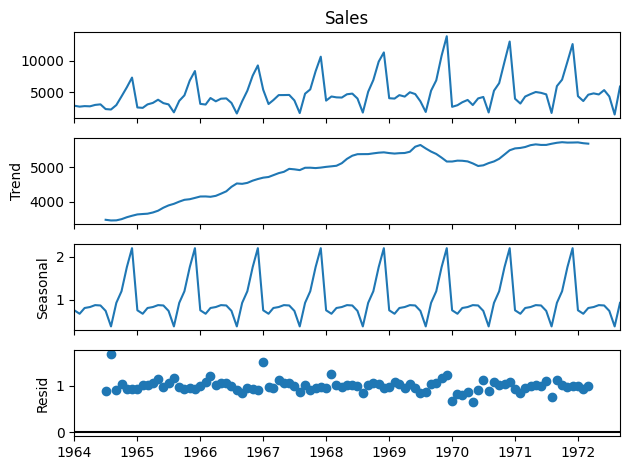

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(df["Sales"], model="additive")
decomposition_additive.plot();

decomposition_multiplicative = seasonal_decompose(df["Sales"], model="multiplicative")
decomposition_multiplicative.plot();

👉 Deseasonalize this time series using the decomposition of your choice

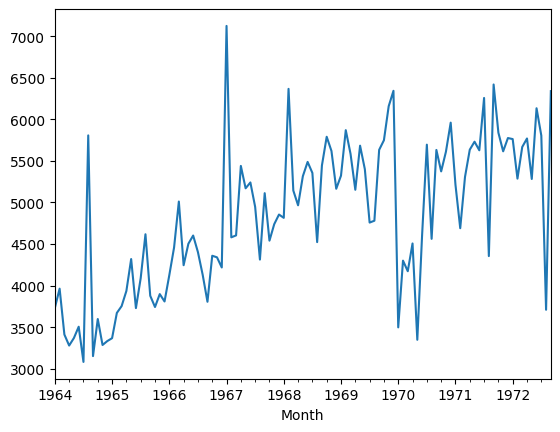

In [12]:
deseasonalized_data = df["Sales"] / decomposition_multiplicative.seasonal
deseasonalized_data.plot();

☝️ We could fit an ARIMA model to the "deseasonalized" version of this time series and recombine after our forecast. However, in this challenge, we will use SARIMA models to fit _directly_ to the original time series!

## 05 - Split the Data (train/test)


For time series, we cannot randomly sample points for the test set. The test set must be "out-of-time", meaning it must strictly be in the future relative to the training set. For this exercise, we will use data up to 1970 for training, and everything after that for testing.

👉 Create `df_train` and `df_test` by splitting the DataFrame with data before 1970 for training and from 1970 onwards for testing

In [13]:
df_train = df[df.index < "1970-01-01"]
df_test = df[df.index >= "1970-01-01"]

## 06 - SARIMA
We will analyze the data using a SARIMA model (Seasonal Auto-Regressive Integrated Moving Average).

What we need to do:
- find how to make the time series stationary (the I in SARIMA)
- find the auto-regressive (AR) part
- find the moving average (MA) part
- find the seasonality (S)

### Step 1: Check Stationarity

If a time series has a trend or seasonal component, it must first be made stationary before we can use ARIMA for forecasting.

A glance at the plot above should be enough to convince you that the time series is not stationary.

Use the [`Augmented Dickey-Fuller test`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html), and in particular its p-value, to re-check the stationarity of `df["Sales"]`

In [31]:
from statsmodels.tsa.stattools import adfuller

adfuller(
    df["Sales"],
    autolag="AIC",
    regression="c",
    maxlag=12
)

(-1.8335930563276166,
 0.36391577166024813,
 11,
 93,
 {'1%': -3.502704609582561,
  '5%': -2.8931578098779522,
  '10%': -2.583636712914788},
 1493.9315183379906)

For 95% confidence in stationarity, the p-value must be less than 0.05.

If the p-value is greater than 0.05, we cannot reject the null hypothesis (null hypothesis = "the process is not stationary").

Ideally, p should be *much* smaller than 0.05.

Another way to look for stationarity is to examine the autocorrelation function (ACF).

Plot the ACF of the time series. You should see a large spike at lag 12, indicating strong annual seasonality.

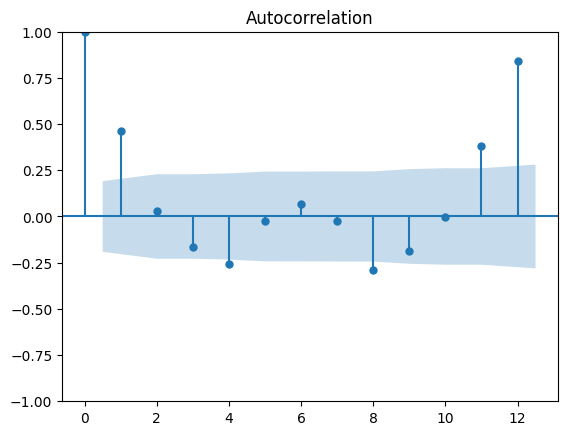

In [24]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["Sales"], lags=12);

### Step 2 - Seasonal Differencing (D)

We have strong seasonality with a 12-month period.

Apply **seasonal differencing at lag 12** to the time series, plot the differenced data, and re-check the ACF plot (+ADF test).

Don't forget to drop NaN values.

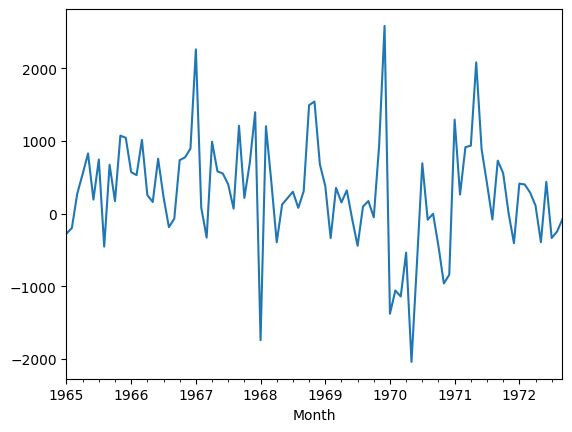

In [25]:
seasonal_diff = df["Sales"].diff(12)
seasonal_diff.dropna(inplace=True)
seasonal_diff.plot();

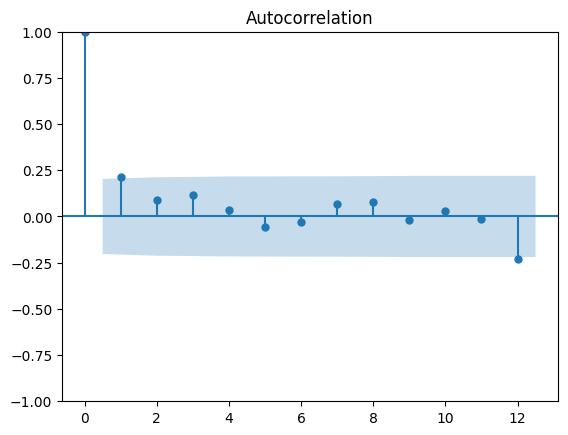

In [26]:
plot_acf(seasonal_diff, lags=12);

adfuller(seasonal_diff);

☝️ A single seasonal differencing appears sufficient to make the TS stationary.
For SARIMA(p,d,q, P,D,Q,m) we choose D=1 (1 seasonal difference) and m=12 (seasonality = 12)

### Step 3 - Differencing (d)

If the time series is still not stationary, it needs to be made stationary through *differencing*. This means taking the difference between each value and the previous one (*first difference*).

Do we need more differencing after removing seasonality?

Check the ACF and ADF after running an additional first-order diff(1) on your diff(12) series.

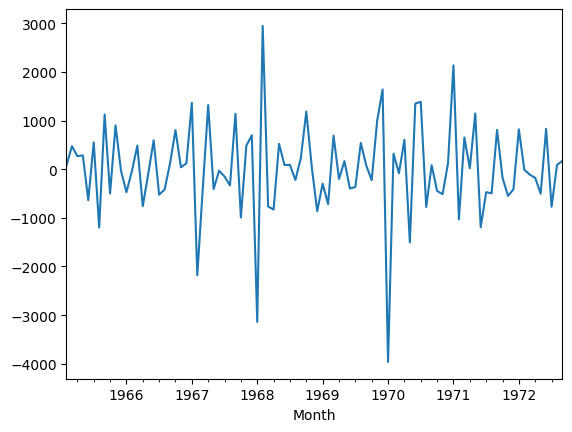

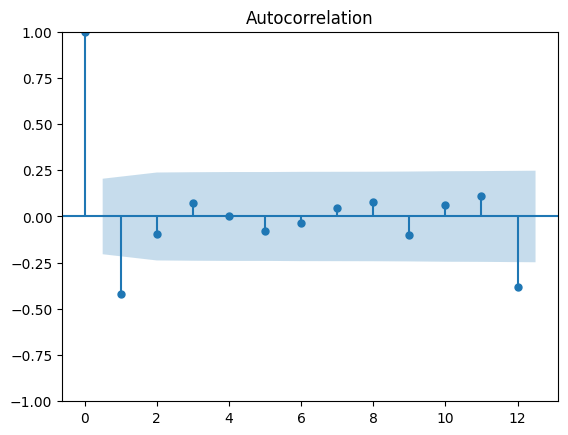

In [30]:
diff_1 = seasonal_diff.diff(1)
diff_1.dropna(inplace=True)
diff_1.plot();
plot_acf(diff_1, lags=12);

adfuller(diff_1);


👉 Additional differencing made both the p-value and ACF worse!
We can choose (d=0) and (D=1)

### Step 4 - Choose AR(p, P) and MA(q, Q) Terms

Now you will use ACF and PACF plots to decide whether to include an AR term, an MA term, or both.

- The autocorrelation plot ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) applied to your **fully differenced** series allows you to choose an MA count (`q`)
- MA($\color{blue}{q}$) = the number of lags where the $\color{blue}{ACF}$ of $Y^{\color{green}{(d+D)}}$ cuts off


- The partial autocorrelation plot [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) applied to your **fully differenced** series allows you to choose AR (`p`)
- AR($\color{red}{p}$) = the number of lags where the $\color{red}{PACF}$ of $Y^{\color{green}{(d+D)}}$ cuts off

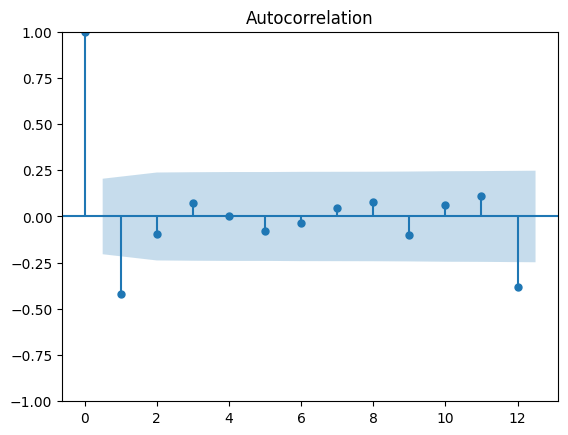

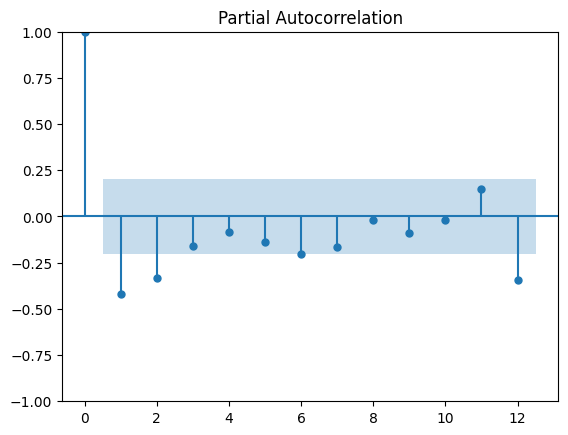

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(diff_1, lags=12);
plot_pacf(diff_1, lags=12);

☝️ There appear to be no significant spikes in either the ACF or PACF, so most likely p=q=0.
Our initial guess for SARIMA is therefore d=0, p=q=0, D=1 and m=12.

How do we find P and Q values? Here, we will let `pmdarima` try values of 0 and 1 for P and Q via grid search.
If you want to find these coefficients yourself, [read this](https://analyticsindiamag.com/quick-way-to-find-p-d-and-q-values-for-arima/) for some practical rules.

👉 Run [auto_arima](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) on the training set. Set seasonal=True, m=12 and D=1. Search p and q, P and Q from 0 to 2. Then print the model summary with model.summary().
Use `njobs=-1, trace=True, error_action='ignore', suppress_warnings=True`

In [35]:
from pmdarima.arima import auto_arima

model = auto_arima(
    df_train,
    seasonal=True,
    m=12,
    d=0,
    D=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    njobs=-1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=954.252, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=957.794, Time=0.06 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=957.973, Time=0.02 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=974.624, Time=0.00 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=956.000, Time=0.01 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=955.904, Time=0.04 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=957.929, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=956.182, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=956.250, Time=0.01 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=958.187, Time=0.03 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 0.216 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                 
================================================================================
Dep. Variable:                        y   No. Observations:                   72
Model:             SARIMAX(0, 1, 0, 12)   Log Likelihood                -475.126
Date:                  Tue, 31 Mar 2026   AIC                            954.252
Time:                          12:40:50   BIC                            958.441
Sample:                      01-01-1964   HQIC                           955.891
                           - 12-01-1969                                         
Covariance Type:                    opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    447.0500     87.035      5.136      0.000     276.464     617.636
sigma2      4.423e+05   5.54e+04      7.979      0.000    3.34e+05    5.51e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                15.13
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               2.45   Skew:                             0.34
Prob(H) (two-sided):                  0.05   Kurtosis:                         5.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The best model found is `ARIMA(0,0,0)(0,1,0)[12]`!
This means that the time series under consideration does not justify adding any "auto-regressive" or "moving average" modeling beyond simple "seasonal differencing".

Such a "weak" model will likely predict only a repetition of the last detected seasonal pattern and an extension of the average increasing trend. Let's check it out.

👉 Use `model.predict` with `n_periods` = length of the test set to store the following three forecasts:
- `central`
- `upper`
- `lower`

Save them as Pandas Series indexed with the same index as your `y_test`

In [36]:
forecast, conf_int = model.predict(n_periods=len(df_test), return_conf_int=True)

central = pd.Series(forecast, index=df_test.index)
upper = pd.Series(conf_int[:, 1], index=df_test.index)
lower = pd.Series(conf_int[:, 0], index=df_test.index)

👇 Run the cell below to compare your forecasts against reality

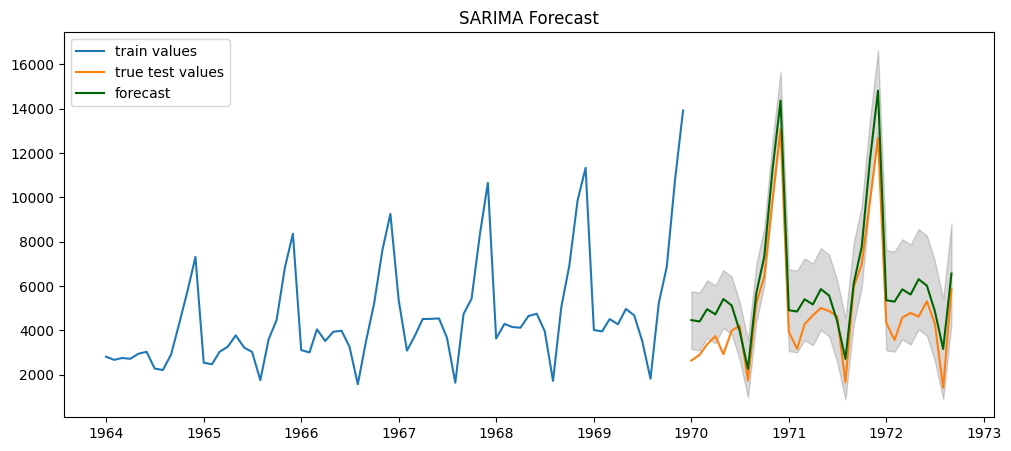

In [37]:
# Plot
plt.figure(figsize=(12, 5), dpi=100)

plt.plot(df_train, label = "train values")
plt.plot(df_test, label = "true test values")
plt.plot(central, color='darkgreen',label = "forecast")

plt.fill_between(
    lower.index,
    lower,
    upper,
    color='k', alpha=.15
)

plt.title("SARIMA Forecast")
plt.legend()
plt.show()

👉 Try assigning non-null values to `p`, `d`, `P`, `D` in your SARIMA and redraw this plot to compare the effects!

# OPTIONAL - Machine Learning Approach

### Model with Only a 1-Month Forecast Horizon

We are now fitting a non-linear model like a Random Forest. The idea is to predict a value from the most recent values.

👉 Create new columns in `df` that are shifted versions of `df['Sales']`. Do this with shifts from 1 to 12.

In [ ]:
# YOUR CODE HERE

👉 Create (do not train) a `random forest` algorithm to predict Sales based on your shifted features

In [ ]:
# YOUR CODE HERE

👉 You can use the function below to test. It takes the true y values (`data` must be a NumPy array), the indices of test samples (`test_indexes`), the predictor (`predictor`: your random forest algorithm), and the shifted columns (`full_X` must be a NumPy array).

In [ ]:
# For each predictor, design a method to evaluate its performance on the test set:
from sklearn.metrics import r2_score

def evaluate_performance_month_prediction(y_true, test_indexes, predictor, full_X):
    predictions = []
    ground_truth = []
    i = 0

    for _index in test_indexes:
        train_data = y_true[:_index]
        current_ground_truth = y_true[_index]
        current_ground_truth_features = full_X[_index,:]
        train_features = full_X[:_index]

        # train the model on all data points until (t-1) to predict (t)
        predictor.fit(train_features, train_data)
        prediction = predictor.predict(current_ground_truth_features.reshape(1,-1))[0]
        predictions.append(prediction)
        ground_truth.append(current_ground_truth)

        i += 1

    mape = np.mean(np.abs(np.array(predictions) - np.array(ground_truth))/np.abs(np.array(ground_truth)))

    return ground_truth, predictions, mape

In [ ]:
# YOUR CODE HERE

We can do feature engineering to improve our model. You will add moving averages to the data used to train the random forest.

Try creating 3 new columns in `df`: one for the moving average of `df[Sales]` with a window of 12, one with a window of 3, and one with a window of 2. This will have the effect of isolating the trend and allowing the algorithm to learn from it. Plot this data.


In [ ]:
# YOUR CODE HERE

You can also add a stronger smoothing predictor using an exponential moving average that statistically optimizes an AR process (hint: the `.ewm` method with `halflife` of 2, 3, and 12). Plot this data.

In [ ]:
# YOUR CODE HERE

You should see a better MAPE!

Try looking at the importance of each feature. What do you find?


In [ ]:
# YOUR CODE HERE

### Out-of-Sample Forecasting Models

Now let's try to beat SARIMA in "out-of-sample" forecasting.

👉 _Train one model per forecast horizon_ (from a `1`-month horizon up to `len(y_test)` months)
👉 Evaluate the MAPE and compare it against SARIMA

In [ ]:
# YOUR CODE HERE